# Análisis Exploratorio de Datos (EDA) - Jugadores y Equipos
**Objetivo:** Realizar un EDA básico sobre el dataset seleccionado, cumpliendo con la consigna de: estadística descriptiva, tipos de variables, relaciones entre variables y visualizaciones.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_csv("../../Datasets/squads_and_players.csv")

# Convertir la fecha de nacimiento y calcular una edad reproducible
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
fecha_referencia = pd.Timestamp('2026-01-01')
df['age'] = ((fecha_referencia - df['date_of_birth']).dt.days / 365.25).round(1)

# Mostramos las primeras 5 filas para comprobar que cargó bien
df.head()

,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals,age
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0,25.9
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3,28.1
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4,28.9
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7,28.2
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3,27.2


## 1. Tipos de Variables
A continuación, utilizamos `.info()` para observar la estructura del dataset, identificar los tipos de datos (categóricos y numéricos) y verificar si existen valores nulos.

In [8]:
# Información general y tipos de datos
df.info()

# Control de calidad del dataset
print(f"Filas y columnas: {df.shape}")
print(f"Registros duplicados: {df.duplicated().sum()}")
display(df.isna().sum().to_frame('valores_nulos'))

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   player_id         1248 non-null   int64         
 1   team_id           1248 non-null   int64         
 2   player_name       1248 non-null   str           
 3   position          1248 non-null   str           
 4   club_team         1248 non-null   str           
 5   market_value_eur  1248 non-null   int64         
 6   caps              1248 non-null   int64         
 7   date_of_birth     1248 non-null   datetime64[us]
 8   height_cm         1248 non-null   int64         
 9   goals             1248 non-null   int64         
 10  age               1248 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(6), str(3)
memory usage: 107.4 KB
Filas y columnas: (1248, 11)
Registros duplicados: 0


,valores_nulos
player_id,0
team_id,0
player_name,0
position,0
club_team,0
market_value_eur,0
caps,0
date_of_birth,0
height_cm,0
goals,0


## 2. Estadística Descriptiva
Calculamos las principales medidas de tendencia central y dispersión para las variables numéricas (como altura, valor de mercado, goles, etc.) y un resumen rápido de frecuencias para las variables categóricas (como posición o club).

In [9]:
# Clasificación de las variables
clasificacion_variables = pd.DataFrame({
    'Variable': df.columns,
    'Tipo en Pandas': df.dtypes.astype(str).values,
    'Clasificación': [
        'Identificador', 'Identificador', 'Categórica nominal', 'Categórica nominal',
        'Categórica nominal', 'Numérica continua', 'Numérica discreta',
        'Fecha', 'Numérica continua', 'Numérica discreta', 'Numérica continua'
    ]
})
display(clasificacion_variables)

# Resumen estadístico de las variables numéricas de interés
columnas_numericas = ['market_value_eur', 'caps', 'height_cm', 'goals', 'age']
display(df[columnas_numericas].describe().round(2))

# Resumen de variables categóricas
columnas_categoricas = ['position', 'club_team']
display(df[columnas_categoricas].describe())

,Variable,Tipo en Pandas,Clasificación
0,player_id,int64,Identificador
1,team_id,int64,Identificador
2,player_name,str,Categórica nominal
3,position,str,Categórica nominal
4,club_team,str,Categórica nominal
5,market_value_eur,int64,Numérica continua
6,caps,int64,Numérica discreta
7,date_of_birth,datetime64[us],Fecha
8,height_cm,int64,Numérica continua
9,goals,int64,Numérica discreta


,market_value_eur,caps,height_cm,goals,age
count,1.248000e+03,1248.00,1248.00,1248.00,1248.00
mean,1.549925e+07,34.99,182.78,4.52,27.50
std,2.345135e+07,32.23,6.83,10.40,4.26
min,2.500000e+04,0.00,160.00,0.00,17.20
25%,2.605922e+06,11.00,178.00,0.00,24.50
50%,6.571762e+06,26.00,183.00,1.00,27.20
75%,1.800000e+07,50.00,188.00,4.00,30.20
max,2.000000e+08,229.00,205.00,143.00,43.00


,position,club_team
count,1248,1248
unique,4,450
top,DEF,Manchester City FC
freq,421,19


## 3. Relaciones entre variables y Visualizaciones
Para entender mejor nuestro dataset, incluimos tres gráficos fundamentales:
1. Un **histograma** para visualizar la distribución de los Valores de Mercado de los jugadores.
2. Un gráfico de **dispersión (scatter plot)** para analizar la relación entre los Partidos Jugados (Caps) y los Goles (Goals).
3. Un **mapa de calor (heatmap)** de correlaciones para identificar qué variables numéricas tienen mayor relación entre sí.

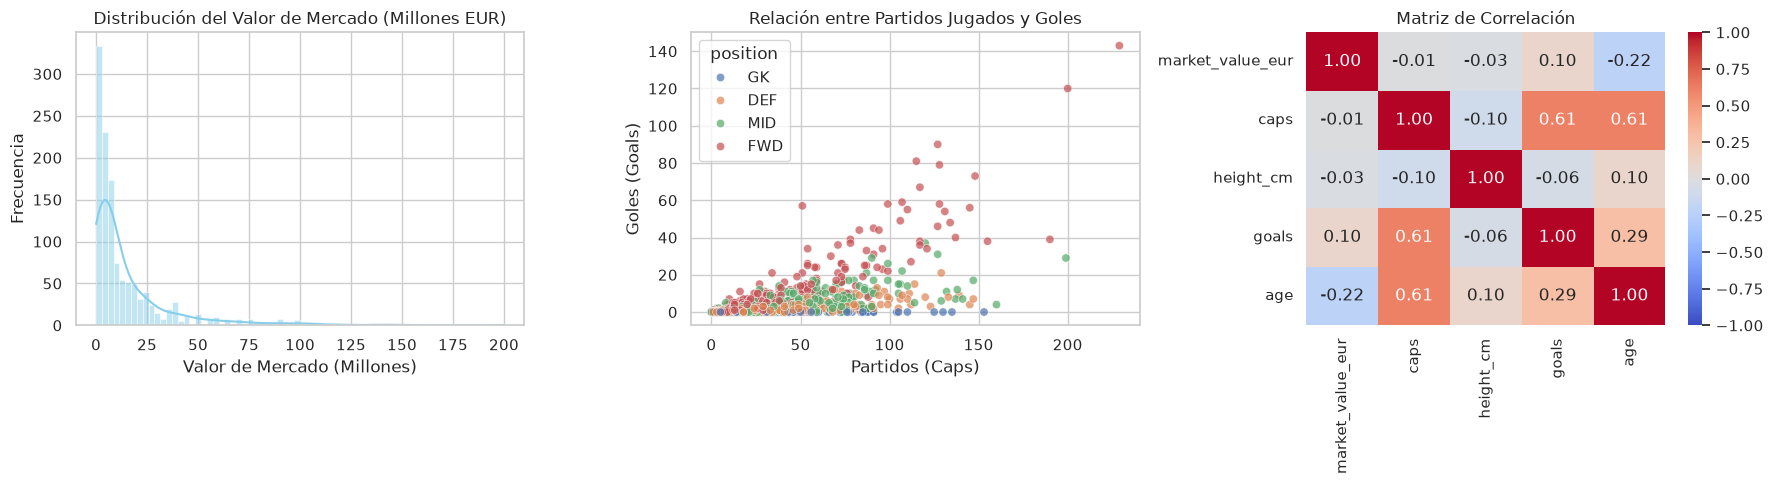

In [10]:
# Configuramos el estilo visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Histograma - Distribución del valor de mercado (en millones)
sns.histplot(df['market_value_eur'] / 1e6, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución del Valor de Mercado (Millones EUR)')
axes[0].set_xlabel('Valor de Mercado (Millones)')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Dispersión - Relación entre Partidos Jugados (Caps) y Goles
sns.scatterplot(data=df, x='caps', y='goals', hue='position', ax=axes[1], alpha=0.7)
axes[1].set_title('Relación entre Partidos Jugados y Goles')
axes[1].set_xlabel('Partidos (Caps)')
axes[1].set_ylabel('Goles (Goals)')

# Gráfico 3: Mapa de calor de correlación de variables numéricas de interés
corr = df[columnas_numericas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=axes[2])
axes[2].set_title('Matriz de Correlación')

plt.tight_layout()
plt.show()

## Observaciones iniciales del EDA
En este dataset, el valor de mercado presenta una distribución asimétrica: la mayoría de los jugadores tiene valores relativamente bajos y unos pocos concentran valores muy altos.

La posición permite diferenciar perfiles: los delanteros suelen concentrar más goles, mientras que los arqueros presentan valores de goles cercanos a cero.

La relación entre partidos jugados (`caps`) y goles es positiva, aunque no perfecta, porque depende de la posición del jugador y de su función en el campo.

La matriz de correlación ayuda a identificar relaciones lineales entre las variables numéricas, pero una correlación no implica causalidad.

## 4. Características generales del dataset
El dataset contiene información de jugadores de distintas selecciones y sus clubes actuales. Cada fila representa a un jugador e incluye datos de identificación, posición, club, valor de mercado, partidos jugados, fecha de nacimiento, altura y goles.

Algunas características relevantes son:
- Tiene 1248 registros y 10 variables originales.
- Contiene 48 equipos o selecciones y 450 clubes.
- Las posiciones disponibles son `GK` (arquero), `DEF` (defensor), `MID` (mediocampista) y `FWD` (delantero).
- Combina variables categóricas, numéricas, identificadores y una fecha.
- El valor de mercado y los goles presentan distribuciones muy asimétricas, debido a la presencia de jugadores destacados.

Un desafío del análisis es que las variables deportivas dependen de la posición: no se espera la misma cantidad de goles para un arquero que para un delantero.

In [3]:
# Resumen de características generales
print(f"Cantidad de jugadores: {len(df)}")
print(f"Cantidad de equipos/selecciones: {df['team_id'].nunique()}")
print(f"Cantidad de clubes: {df['club_team'].nunique()}")
print("\nCantidad de jugadores por posición:")
display(df['position'].value_counts().rename_axis('position').to_frame('cantidad'))
print("10 clubes con mayor cantidad de jugadores:")
display(df['club_team'].value_counts().head(10).rename_axis('club_team').to_frame('cantidad'))

Cantidad de jugadores: 1248
Cantidad de equipos/selecciones: 48
Cantidad de clubes: 450

Cantidad de jugadores por posición:


,cantidad
position,
DEF,421
MID,369
FWD,313
GK,145


10 clubes con mayor cantidad de jugadores:


,cantidad
club_team,
Manchester City FC,19
FC Bayern München,17
Paris Saint-Germain,16
Arsenal FC,15
FC Barcelona,15
Atlético De Madrid,12
Manchester United FC,12
Al Hilal SC,12
Crystal Palace FC,12


## 5. Datos faltantes
Se revisan los valores faltantes porque pueden afectar los resúmenes estadísticos y las visualizaciones.

En este dataset no se detectaron valores nulos. Por lo tanto, no fue necesario aplicar imputación ni eliminar registros. Como no existen faltantes observados, no es posible determinar si el mecanismo de ausencia sería MCAR, MAR, MNAR o estructural.

In [4]:
# Cantidad y porcentaje de datos faltantes por columna
faltantes = pd.DataFrame({
    'cantidad': df.isna().sum(),
    'porcentaje': (df.isna().mean() * 100).round(2)
})
display(faltantes)

,cantidad,porcentaje
player_id,0,0.0
team_id,0,0.0
player_name,0,0.0
position,0,0.0
club_team,0,0.0
market_value_eur,0,0.0
caps,0,0.0
date_of_birth,0,0.0
height_cm,0,0.0
goals,0,0.0


## 6. Identificación de outliers
Un outlier es una observación que se encuentra alejada del comportamiento habitual de una variable. Para detectarlos se utiliza la regla del rango intercuartílico (IQR):

- Límite inferior: $Q1 - 1.5 \times IQR$
- Límite superior: $Q3 + 1.5 \times IQR$

Los valores identificados se consideran posibles outliers. No se eliminan automáticamente: primero se debe verificar si son errores o casos reales del dominio.

In [5]:
# Detección de posibles outliers mediante la regla IQR
columnas_outliers = ['market_value_eur', 'caps', 'height_cm', 'goals']
resumen_outliers = []
outliers_por_columna = {}

for columna in columnas_outliers:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    mascara = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    outliers_por_columna[columna] = df.loc[mascara, ['player_name', 'position', columna]]
    resumen_outliers.append({
        'variable': columna,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'posibles_outliers': int(mascara.sum())
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
display(resumen_outliers.round(2))

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,posibles_outliers
0,market_value_eur,2605921.75,18000000.0,15394078.25,-20485195.62,41091117.38,113
1,caps,11.00,50.0,39.00,-47.50,108.50,48
2,height_cm,178.00,188.0,10.00,163.00,203.00,2
3,goals,0.00,4.0,4.00,-6.00,10.00,133


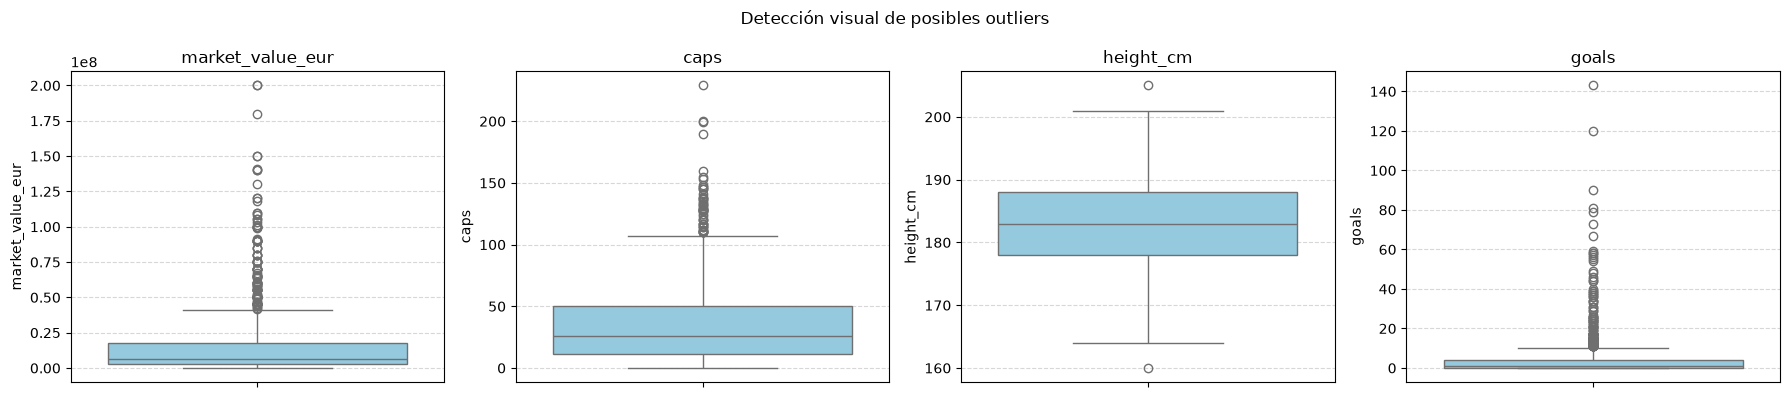

In [6]:
# Visualización de outliers en variables numéricas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for eje, columna in zip(axes, columnas_outliers):
    sns.boxplot(y=df[columna], ax=eje, color='skyblue')
    eje.set_title(columna)
    eje.grid(axis='y', linestyle='--', alpha=0.5)
plt.suptitle('Detección visual de posibles outliers')
plt.tight_layout()
plt.show()

In [11]:
# Ejemplos de posibles outliers para interpretar según el dominio
for columna in ['market_value_eur', 'caps', 'height_cm', 'goals']:
    print(f"\nValores extremos de {columna}:")
    display(outliers_por_columna[columna].sort_values(columna, ascending=False).head(5))


Valores extremos de market_value_eur:


,player_name,position,market_value_eur
746,Lamine Yamal Yamal,FWD,200000000
918,Erling Braut Haaland,FWD,200000000
841,Kylian Mbappe,FWD,180000000
842,Michael Akpovie Olise,FWD,150000000
747,Pedro Pedri,MID,150000000



Valores extremos de caps:


,player_name,position,caps
1046,Ronaldo Cristiano Ronaldo,FWD,229
945,Lionel Andrés Messi,FWD,200
1179,Luka Modric,MID,199
165,Khalid Hassan Alhaydos,FWD,190
1241,Anibal Casis Godoy,MID,160



Valores extremos de height_cm:


,player_name,position,height_cm
999,Florian Wiegele,GK,205
1242,Cesar Augusto Yanis,MID,160



Valores extremos de goals:


,player_name,position,goals
1046,Ronaldo Cristiano Ronaldo,FWD,143
945,Lionel Andrés Messi,FWD,120
632,Romelu Lukaku,FWD,90
1152,Harry Edward Kane,FWD,81
217,Neymar Neymar Jr,FWD,79


### Interpretación de los outliers
La regla IQR identifica valores alejados del centro de la distribución, pero no determina por sí sola que sean errores. En este dataset, los valores altos de `market_value_eur`, `caps` y `goals` pueden corresponder a jugadores destacados con gran trayectoria o cotización.

Por ejemplo, aparecen jugadores con muchos partidos y goles, como Cristiano Ronaldo, Lionel Messi y otros delanteros reconocidos. Estos registros son casos extremos pero plausibles, por lo que se conservan. En cambio, los valores extremos de `height_cm` deberían revisarse individualmente para confirmar que no existan errores de carga.

La técnica aplicada será entonces identificar, visualizar y documentar los posibles outliers, sin eliminarlos automáticamente.

## 7. Conclusión final
El dataset es adecuado para un análisis exploratorio porque combina información numérica, categórica y temporal de 1248 jugadores.

No se encontraron datos faltantes ni registros duplicados. La regla IQR detectó posibles outliers en valor de mercado, partidos jugados, altura y goles. Estos valores no se eliminaron automáticamente porque pueden representar jugadores reales con gran trayectoria, rendimiento o cotización.

Como siguiente paso, si se quisiera construir un modelo predictivo, sería conveniente analizar los valores extremos por posición y equipo, revisar los registros atípicos individualmente y considerar transformaciones para variables muy asimétricas como el valor de mercado.